# Noise-multiplier sweep results (BgB, 5.12M steps, 3 seeds)

Pulls the visible runs from W&B and plots (1) return vs. noise multiplier, (2) learning curves,
(3) per-sensor SNR over training from the `obsstats` run.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, wandb
from pathlib import Path

ENTITY, PROJECT = "models-imperial-college-london8968", "plasmax"
SNR_RUN_ID = "4s4lh8gc"  # obsstats run (0x, 5.12M, post RMS/per-seed-SNR fix)
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

api = wandb.Api()

def find(d, k):
    if isinstance(d, dict):
        for kk, v in d.items():
            if kk == k:
                return v
            x = find(v, k)
            if x is not None:
                return x

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/davidcoope/.netrc.


## 1. Load the sweep runs
Explicit run IDs for the runs visible in the W&B workspace (visibility isn't exposed by the API). Each ID is checked against its logged `noise_multiplier`.

In [2]:
RET = ["evaluation/return_mean", "evaluation/return_min", "evaluation/return_max", "evaluation/return_std"]
KEYS = RET + [k + "_seed_std" for k in RET]

VISIBLE = {0: "yzeh8hs6", 1: "h4w85xzn", 2: "e008yuei", 5: "robmwd7s",
           6: "gnfb2k0r", 7: "fgosx29y", 10: "ovhwj1vl", 25: "2791b0oj"}
PARTIAL = {25: "3dvbc16h"}  # crashed at 3.07M steps; learning curve only

def load(nm, rid):
    r = api.run(f"{ENTITY}/{PROJECT}/{rid}")
    assert find(r.config, "noise_multiplier") == nm, (nm, rid)
    return r.history(samples=10000, keys=KEYS, pandas=True).dropna(subset=RET[:1])

hist = {nm: load(nm, rid) for nm, rid in VISIBLE.items()}
partial = {nm: load(nm, rid) for nm, rid in PARTIAL.items()}

In [3]:
final = pd.DataFrame({nm: h.iloc[-1] for nm, h in hist.items()}).T
final.index.name = "noise_multiplier"
final = final.drop(columns="_step", errors="ignore")
final.columns = [c.replace("evaluation/", "") for c in final.columns]
final.round(1)

,return_mean,return_min,return_max,return_std,return_mean_seed_std,return_min_seed_std,return_max_seed_std,return_std_seed_std
noise_multiplier,,,,,,,,
0,775.7,559.2,818.5,72.9,103.3,447.1,64.1,119.5
1,763.1,550.7,800.8,60.3,55.8,397.2,21.2,95.3
2,765.4,541.4,822.1,84.1,99.6,460.0,23.9,136.4
5,849.5,634.9,873.1,50.9,45.7,394.8,24.4,79.1
6,838.6,663.3,867.8,51.2,56.7,330.8,31.8,78.2
7,838.7,597.4,864.8,57.4,50.9,419.6,40.7,89.3
10,788.1,546.7,824.0,62.8,76.4,415.2,72.1,96.0
25,578.9,214.3,700.1,150.2,48.2,337.7,53.2,120.5


## 2. Final return vs. noise multiplier

In [4]:
# Profile-sensor SNR=1 crossing: SNR falls as 1/multiplier, so the crossing multiplier
# equals each profile sensor's SNR at the reference (0x-trained) run.
snr_run = api.run(f"{ENTITY}/{PROJECT}/{SNR_RUN_ID}")
SENSORS = ["T_e", "T_i", "n_e", "W_thermal", "P_fusion", "q_min", "q95", "beta_N", "tau_E", "f_non_inductive"]
snr_keys = [f"obs_{p}/{s}/snr{suf}" for p in ("train", "eval") for s in SENSORS for suf in ("", "_seed_std")]
snr = snr_run.history(samples=10000, keys=snr_keys, pandas=True).set_index("_step")
cross = snr.loc[snr.index.max(), [f"obs_eval/{s}/snr" for s in ("T_e", "T_i", "n_e")]]
lo, hi = cross.min(), cross.max()
print(cross.round(2).to_dict(), "-> profile SNR=1 band: %.1fx to %.1fx" % (lo, hi))

{'obs_eval/T_e/snr': 6.31, 'obs_eval/T_i/snr': 6.57, 'obs_eval/n_e/snr': 5.45} -> profile SNR=1 band: 5.4x to 6.6x


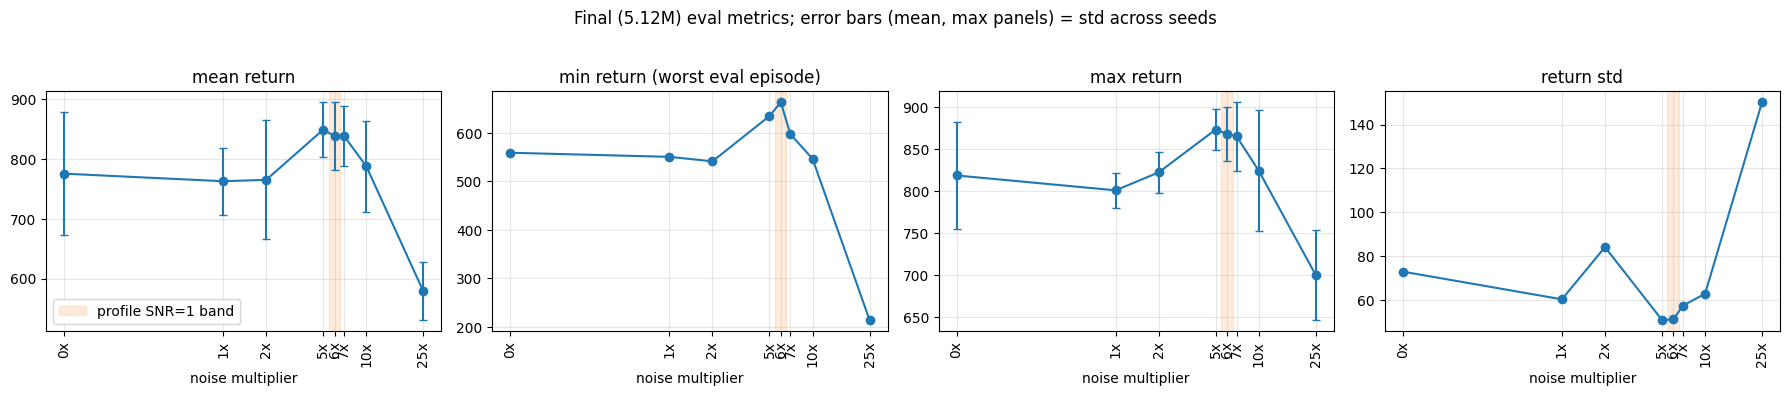

In [5]:
x = final.index.values.astype(float)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, stat, title in zip(axes, ["return_mean", "return_min", "return_max", "return_std"],
                           ["mean return", "min return (worst eval episode)", "max return", "return std"]):
    y, e = final[stat].values, final[stat + "_seed_std"].values
    ax.errorbar(x, y, yerr=e if stat in ("return_mean", "return_max") else None, fmt="o-", capsize=3)
    ax.axvspan(lo, hi, color="C1", alpha=0.15, label="profile SNR=1 band")
    ax.set_xscale("symlog", linthresh=1); ax.set_xticks(x); ax.set_xticklabels([f"{v:g}x" for v in x], rotation=90)
    ax.set_title(title); ax.set_xlabel("noise multiplier"); ax.grid(alpha=0.3)
axes[0].legend()
fig.suptitle("Final (5.12M) eval metrics; error bars (mean, max panels) = std across seeds", y=1.03)
fig.tight_layout(); save(fig, "final_metrics_vs_multiplier"); plt.show()

## 3. Learning curves

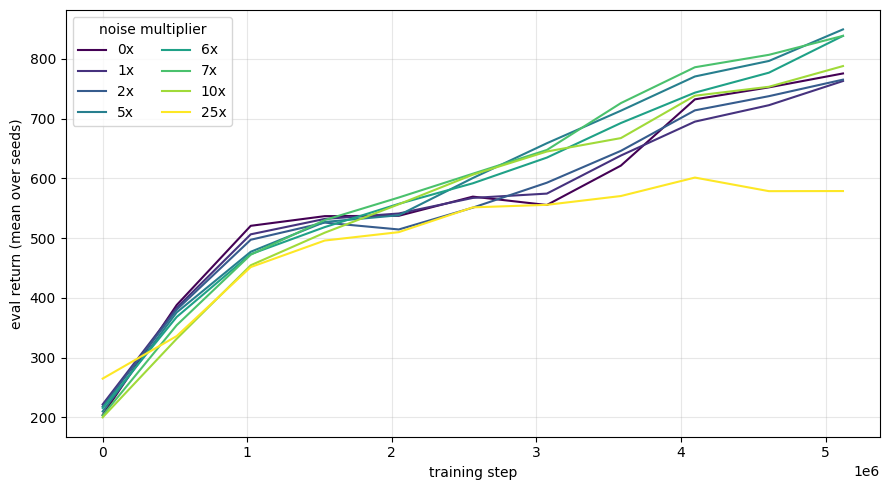

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.get_cmap("viridis")
for i, (nm, h) in enumerate(hist.items()):
    c = cmap(i / max(len(hist) - 1, 1))
    ax.plot(h["_step"], h["evaluation/return_mean"], color=c, label=f"{nm:g}x")
ax.set_xlabel("training step"); ax.set_ylabel("eval return (mean over seeds)")
ax.legend(title="noise multiplier", ncol=2); ax.grid(alpha=0.3)
fig.tight_layout(); save(fig, "learning_curves"); plt.show()

## 4. Per-sensor SNR over training (obsstats run, 0x)
SNR = signal std / noise std at 1x, computed per seed then averaged. Above 1 = signal-dominated. Step 0 is the pre-training checkpoint.

In [7]:
snr_eval = snr[[f"obs_eval/{s}/snr" for s in SENSORS]]
snr_eval.columns = SENSORS
snr_train = snr[[f"obs_train/{s}/snr" for s in SENSORS]]
snr_train.columns = SENSORS
snr_train = snr_train.iloc[1:]  # drop step 0: no completed training window, all NaN

groups = {"profiles": ["T_e", "T_i", "n_e"],
          "scalars": ["W_thermal", "P_fusion", "beta_N", "tau_E", "f_non_inductive"],
          "stability (q)": ["q_min", "q95"]}

def plot_snr(df, prefix, label, fname):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, (g, cols) in zip(axes, groups.items()):
        for s in cols:
            ax.errorbar(df.index, df[s].astype(float), yerr=snr[f"{prefix}/{s}/snr_seed_std"].reindex(df.index).astype(float), marker="o", capsize=2, label=s)
        ax.axhline(1, color="k", ls="--", lw=1)
        ax.set_yscale("log"); ax.set_title(f"{g} ({label})"); ax.set_xlabel("training step")
        ax.grid(alpha=0.3, which="both"); ax.legend()
    axes[0].set_ylabel(f"SNR ({label}, 1x noise)")
    fig.suptitle(f"{label.upper()} SNR over training; error bars = std across seeds", y=1.03)
    fig.tight_layout(); save(fig, fname); plt.show()

### EVAL SNR - Data
Measured on the eval rollouts at each checkpoint (deterministic policy).

In [8]:
snr_eval.round(3)

,T_e,T_i,n_e,W_thermal,P_fusion,q_min,q95,beta_N,tau_E,f_non_inductive
_step,,,,,,,,,,
0.0,6.187,6.380,4.666,0.950,2.058,0.025,0.010,0.950,0.731,0.931
512000.0,6.222,6.551,4.694,0.668,1.269,0.023,0.009,0.668,0.580,0.795
1024000.0,6.246,6.652,4.668,0.398,0.732,0.022,0.006,0.398,0.418,0.662
1536000.0,6.250,6.663,4.693,0.326,0.630,0.022,0.008,0.326,0.356,0.634
2048000.0,6.261,6.671,4.668,0.339,0.659,0.024,0.008,0.339,0.357,0.720
2560000.0,6.289,6.653,4.763,0.335,0.637,0.025,0.008,0.335,0.366,0.799
3072000.0,6.317,6.622,4.902,0.310,0.593,0.032,0.007,0.310,0.357,0.792
3584000.0,6.320,6.597,5.124,0.286,0.546,0.041,0.009,0.286,0.341,0.747
4096000.0,6.308,6.590,5.291,0.266,0.479,0.034,0.008,0.266,0.331,0.715


### TRAIN SNR - Data
Measured on the training data collected in the window ending at each checkpoint.

In [9]:
snr_train.round(3)

,T_e,T_i,n_e,W_thermal,P_fusion,q_min,q95,beta_N,tau_E,f_non_inductive
_step,,,,,,,,,,
512000.0,6.209323,6.463289,4.827816,1.009661,2.085999,0.055204,0.017402,1.009692,0.702826,0.944596
1024000.0,6.239134,6.616637,4.691074,0.685378,1.298335,0.041344,0.012388,0.685357,0.581077,0.754781
1536000.0,6.246507,6.658642,4.668807,0.355691,0.661853,0.029719,0.007135,0.355695,0.400309,0.628918
2048000.0,6.25314,6.666762,4.669291,0.309688,0.595486,0.026914,0.008986,0.309683,0.354737,0.643246
2560000.0,6.271602,6.667901,4.664244,0.32766,0.606429,0.08551,0.010601,0.327645,0.369686,0.840556
3072000.0,6.303023,6.644108,4.776707,0.330834,0.612636,0.097167,0.010509,0.330817,0.377804,0.850123
3584000.0,6.323983,6.613187,4.9546,0.334247,0.632483,0.065718,0.009567,0.334264,0.35471,0.798333
4096000.0,6.317017,6.594778,5.177583,0.297488,0.597422,0.107459,0.008677,0.297493,0.337426,0.733735
4608000.0,6.312065,6.588311,5.295034,0.395277,0.735666,0.081123,0.011499,0.395289,0.358439,0.794427


### EVAL SNR plot over training, by sensor group
Error bars = std across the 3 seeds.

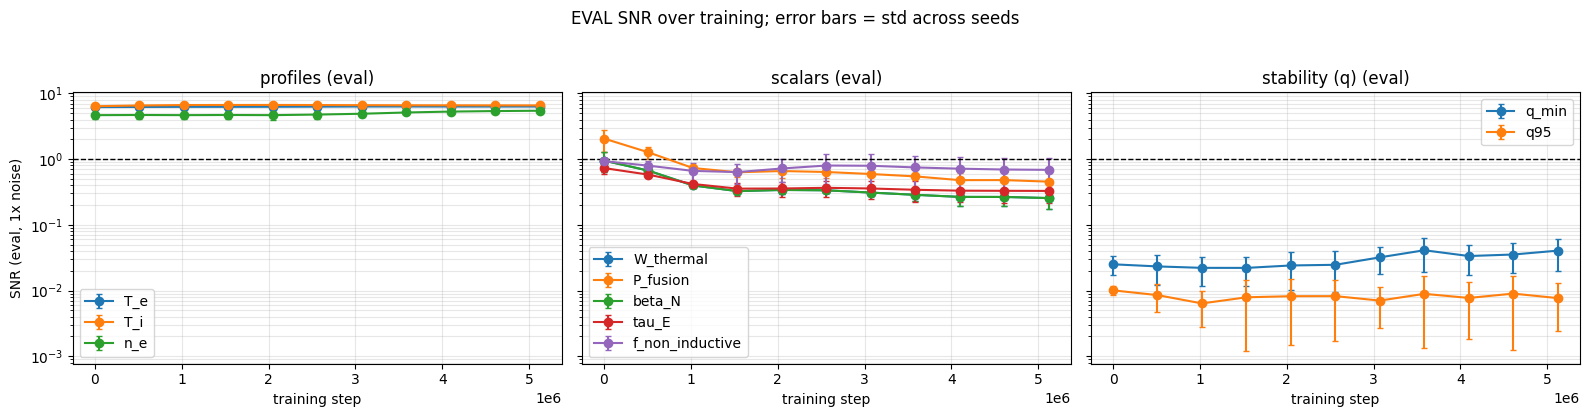

In [10]:
plot_snr(snr_eval, "obs_eval", "eval", "snr_over_training_eval")

### TRAIN SNR plot over training, by sensor group
Step 0 is dropped because no training window has completed yet.

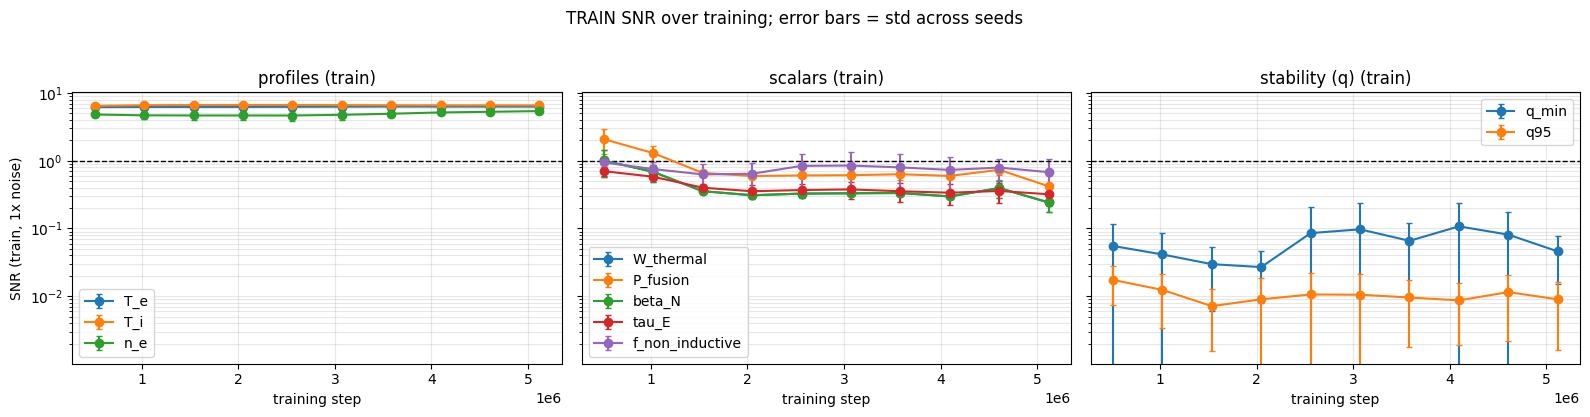

In [11]:
plot_snr(snr_train, "obs_train", "train", "snr_over_training_train")